In [ ]:
   #استيراد للمكاتب
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [ ]:
# تحميل الداتاسيت 
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
path
# تحميل بيانات
df = pd.read_csv(path + "/heart.csv")
df
# عدد الصفوف اللي مكررة 
print("عدد الصفوف المكررة:", df.duplicated().sum())

# حذفت الصفوف المكررة واحتفظت بصف واحد بس من المكرر
df = df.drop_duplicates()
print("عدد الصفوف بعد الحذف:", df.shape)
#معلومات كنظرة عامة
df.info()

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
عدد الصفوف المكررة: 723
عدد الصفوف بعد الحذف: (302, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


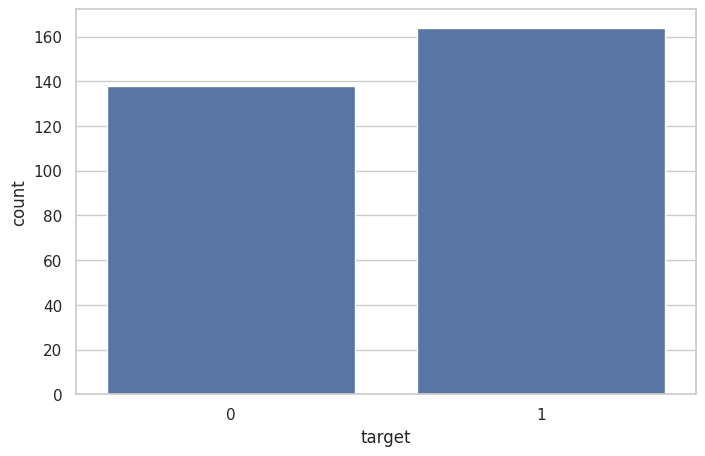

In [24]:
# مصاب (1) وغير مصاب (0)
sns.countplot(x='target', data=df)
plt.show()


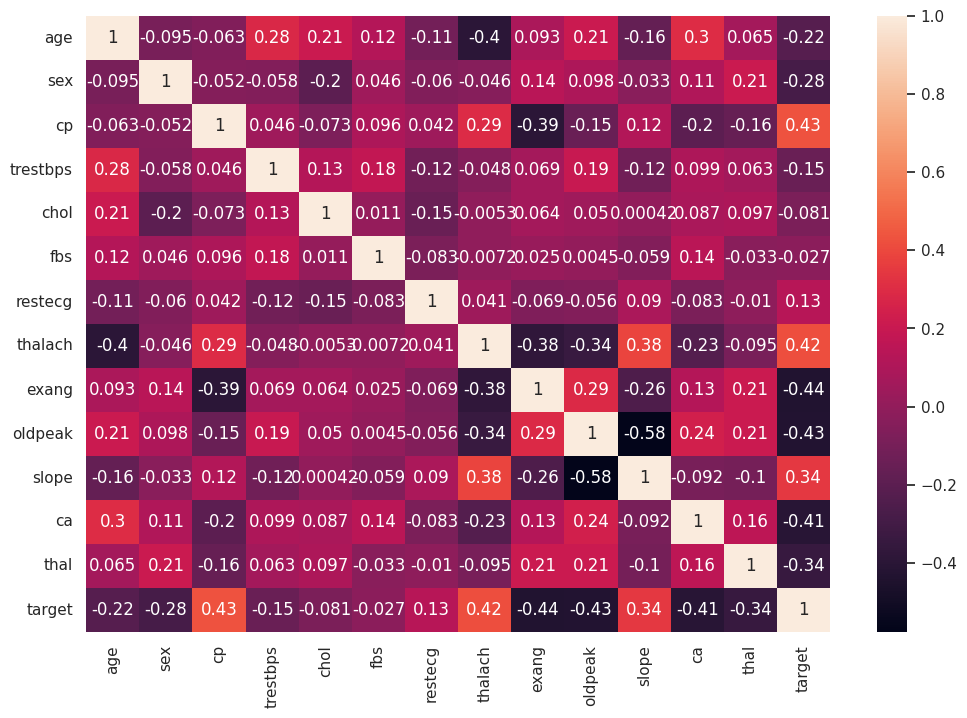

In [25]:
# المخطط الحراري حتى اظهرر الارتباط بين كل المتغيرات مع بعضها
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [26]:

X = df.drop('target', axis=1)
y = df['target']
# قسمت البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [27]:
# حساب مقاييس ال evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.7540983606557377
Precision: 0.7647058823529411
Recall   : 0.7878787878787878
F1-score : 0.7761194029850746


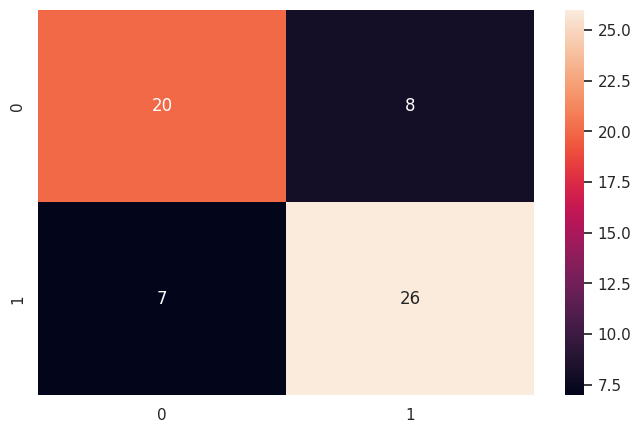

In [28]:
# مصفوفة الالتباس
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()